# Student Performance - EDA

This notebook explores the Student performance dataset to understand the structure of the data, identify important patterns, and prepare the dataset for Machine Learning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset

This project uses the [Student Career Success Prediction Dataset](https://www.kaggle.com/datasets/mobeenfatimah/student-career-success-prediction-dataset) created by Mobeen Fatima.

The dataset is synthetic and was obtained from Kaggle. The original dataset project is licensed under the Apache License 2.0.

This repository does not claim ownership of the original dataset.

In [2]:
data = pd.read_csv("data/student_career_success_dataset.csv")

In [3]:
data.head()

,Student_ID,Age,Gender,University_Year,Major,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Academic_Performance,Programming_Skill,...,Teamwork,Problem_Solving,English_Proficiency,Interview_Score,Employability_Score,Placement_Status,Company_Tier,Career_Field,Placement_Mode,Starting_Salary_USD
0,ST000001,22,Male,Sophomore,Computer Science,86,21,3.28,Good,9,...,7,8,Advanced,72,231.70,Placed,Tier 1,Backend Developer,Campus Placement,72082
1,ST000002,20,Female,Freshman,Computer Science,64,18,2.53,Poor,6,...,6,5,Basic,59,157.45,Not Placed,No Company,Not Placed,Not Applicable,0
2,ST000003,23,Male,Senior,Information Technology,75,19,2.83,Average,8,...,8,7,Advanced,76,203.45,Placed,Tier 1,IT Support Engineer,Campus Placement,94898
3,ST000004,23,Female,Senior,Information Technology,80,19,2.80,Average,5,...,6,6,Intermediate,67,171.50,Not Placed,No Company,Not Placed,Not Applicable,0
4,ST000005,23,Female,Senior,Software Engineering,73,19,2.93,Average,9,...,8,9,Advanced,82,225.45,Placed,Tier 1,Software Engineer,Internship Conversion,85256


In [4]:
print(f"No. of rows/datapoints : {data.shape[0]} \nNo. of columns/features : {data.shape[1]}")

No. of rows/datapoints : 50000 
No. of columns/features : 29


In [5]:
data.columns

Index(['Student_ID', 'Age', 'Gender', 'University_Year', 'Major',
       'Attendance_Percentage', 'Study_Hours_Per_Week', 'CGPA',
       'Academic_Performance', 'Programming_Skill', 'Projects_Completed',
       'Certifications', 'Hackathons', 'GitHub_Profile', 'Internships',
       'Leadership_Experience', 'LinkedIn_Profile', 'Resume_Score',
       'Communication_Skills', 'Teamwork', 'Problem_Solving',
       'English_Proficiency', 'Interview_Score', 'Employability_Score',
       'Placement_Status', 'Company_Tier', 'Career_Field', 'Placement_Mode',
       'Starting_Salary_USD'],
      dtype='str')

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             50000 non-null  str    
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  str    
 3   University_Year        50000 non-null  str    
 4   Major                  50000 non-null  str    
 5   Attendance_Percentage  50000 non-null  int64  
 6   Study_Hours_Per_Week   50000 non-null  int64  
 7   CGPA                   50000 non-null  float64
 8   Academic_Performance   50000 non-null  str    
 9   Programming_Skill      50000 non-null  int64  
 10  Projects_Completed     50000 non-null  int64  
 11  Certifications         50000 non-null  int64  
 12  Hackathons             50000 non-null  int64  
 13  GitHub_Profile         50000 non-null  str    
 14  Internships            50000 non-null  int64  
 15  Leadership_Ex

In [7]:
data.describe()

,Age,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Programming_Skill,Projects_Completed,Certifications,Hackathons,Internships,Resume_Score,Communication_Skills,Teamwork,Problem_Solving,Interview_Score,Employability_Score,Starting_Salary_USD
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,21.262900,81.409640,21.52816,3.106043,7.137160,8.620560,1.715660,3.093940,4.048880,96.045740,8.435780,7.006200,7.175060,77.515400,213.991394,68988.167480
std,2.041163,9.709519,6.97481,0.290351,1.507194,2.505408,1.368301,1.660774,1.005719,7.331565,1.387543,1.606802,1.674428,12.579382,26.824224,38480.607679
min,18.000000,50.000000,5.00000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,44.000000,3.000000,2.000000,1.000000,17.000000,82.300000,0.000000
25%,20.000000,75.000000,17.00000,2.910000,6.000000,7.000000,1.000000,2.000000,3.000000,95.000000,7.000000,6.000000,6.000000,70.000000,197.350000,65229.250000
50%,21.000000,82.000000,21.00000,3.110000,7.000000,9.000000,2.000000,3.000000,4.000000,100.000000,9.000000,7.000000,7.000000,78.000000,217.250000,83044.500000
75%,22.000000,88.000000,26.00000,3.310000,8.000000,10.000000,3.000000,4.000000,5.000000,100.000000,10.000000,8.000000,8.000000,87.000000,233.600000,96486.250000
max,30.000000,100.000000,45.00000,4.000000,10.000000,15.000000,8.000000,10.000000,5.000000,100.000000,10.000000,10.000000,10.000000,100.000000,279.050000,110000.000000


In [8]:
data.isnull().sum()

Student_ID               0
Age                      0
Gender                   0
University_Year          0
Major                    0
Attendance_Percentage    0
Study_Hours_Per_Week     0
CGPA                     0
Academic_Performance     0
Programming_Skill        0
Projects_Completed       0
Certifications           0
Hackathons               0
GitHub_Profile           0
Internships              0
Leadership_Experience    0
LinkedIn_Profile         0
Resume_Score             0
Communication_Skills     0
Teamwork                 0
Problem_Solving          0
English_Proficiency      0
Interview_Score          0
Employability_Score      0
Placement_Status         0
Company_Tier             0
Career_Field             0
Placement_Mode           0
Starting_Salary_USD      0
dtype: int64

In [9]:
data["University_Year"].value_counts()


University_Year
Junior       14870
Senior       12658
Sophomore    12634
Freshman      9838
Name: count, dtype: int64

In [10]:
data["Major"].value_counts()

Major
Computer Science           12407
Software Engineering        7516
Artificial Intelligence     7505
Data Science                6116
Cybersecurity               4975
Information Technology      4906
Business Analytics          4027
Electrical Engineering      2548
Name: count, dtype: int64

In [11]:
data["Placement_Status"].value_counts()

Placement_Status
Placed        39040
Not Placed    10960
Name: count, dtype: int64

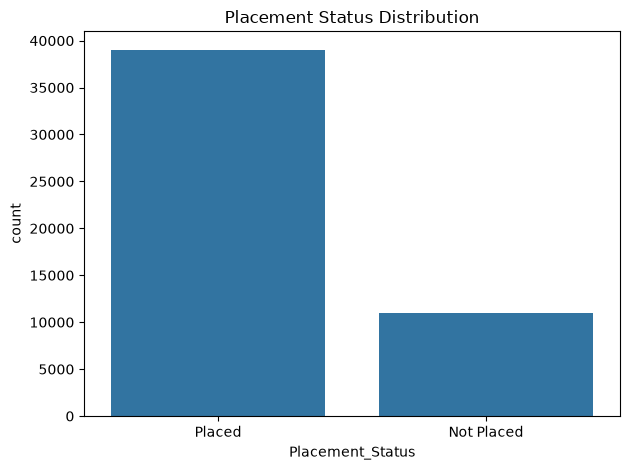

In [12]:
sns.countplot(data=data,x="Placement_Status")
plt.title("Placement Status Distribution")
plt.tight_layout()
plt.show()

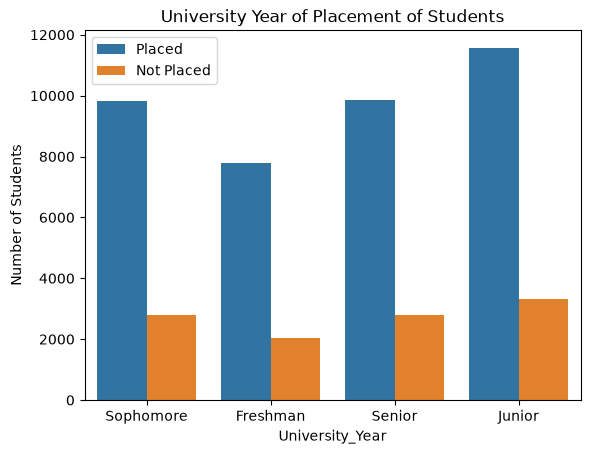

In [13]:
sns.countplot(data=data,x="University_Year",hue="Placement_Status")
plt.title("University Year of Placement of Students")
plt.ylabel("Number of Students")
plt.legend()

In [14]:
df = data.copy()

In [15]:
df["Placement_Status"]=df["Placement_Status"].map(
    {
        "Placed" : 1,
        "Not Placed" : 0
    }
)
df = df.drop(columns=['Student_ID','Company_Tier','Career_Field','Placement_Mode','Starting_Salary_USD'])
df = df.select_dtypes(exclude="str")

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    50000 non-null  int64  
 1   Attendance_Percentage  50000 non-null  int64  
 2   Study_Hours_Per_Week   50000 non-null  int64  
 3   CGPA                   50000 non-null  float64
 4   Programming_Skill      50000 non-null  int64  
 5   Projects_Completed     50000 non-null  int64  
 6   Certifications         50000 non-null  int64  
 7   Hackathons             50000 non-null  int64  
 8   Internships            50000 non-null  int64  
 9   Resume_Score           50000 non-null  int64  
 10  Communication_Skills   50000 non-null  int64  
 11  Teamwork               50000 non-null  int64  
 12  Problem_Solving        50000 non-null  int64  
 13  Interview_Score        50000 non-null  int64  
 14  Employability_Score    50000 non-null  float64
 15  Placement_Sta

In [17]:
corrMtrx = df.corr()
corrMtrx

,Age,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Programming_Skill,Projects_Completed,Certifications,Hackathons,Internships,Resume_Score,Communication_Skills,Teamwork,Problem_Solving,Interview_Score,Employability_Score,Placement_Status
Age,1.000000,0.002119,-0.001698,-0.000976,0.008679,0.010230,-0.006526,0.003476,0.004827,0.005767,0.002272,0.007132,0.001245,0.008255,0.006908,0.000412
Attendance_Percentage,0.002119,1.000000,-0.002376,0.667727,0.253053,0.159540,0.116256,0.113290,0.300283,0.224345,0.154020,0.071011,0.371952,0.266755,0.403592,0.184865
Study_Hours_Per_Week,-0.001698,-0.002376,1.000000,0.533161,0.200839,0.118428,0.095808,0.088229,0.232557,0.166050,0.112742,0.050155,0.299398,0.213467,0.317465,0.141672
CGPA,-0.000976,0.667727,0.533161,1.000000,0.379843,0.231492,0.176689,0.168589,0.445446,0.323818,0.223603,0.100466,0.560389,0.399674,0.601362,0.270335
Programming_Skill,0.008679,0.253053,0.200839,0.379843,1.000000,0.601406,0.070893,0.438893,0.462807,0.601535,0.283528,0.263677,0.736964,0.651221,0.814310,0.370803
Projects_Completed,0.010230,0.159540,0.118428,0.231492,0.601406,1.000000,0.039354,0.262996,0.627914,0.651236,0.371687,0.210937,0.443158,0.533144,0.752465,0.344400
Certifications,-0.006526,0.116256,0.095808,0.176689,0.070893,0.039354,1.000000,0.029577,0.078540,0.178882,0.037708,0.012655,0.098983,0.088693,0.194933,0.084712
Hackathons,0.003476,0.113290,0.088229,0.168589,0.438893,0.262996,0.029577,1.000000,0.201162,0.269416,0.176589,0.498170,0.323848,0.294212,0.364893,0.169405
Internships,0.004827,0.300283,0.232557,0.445446,0.462807,0.627914,0.078540,0.201162,1.000000,0.696083,0.508538,0.158430,0.429653,0.593748,0.789657,0.392040
Resume_Score,0.005767,0.224345,0.166050,0.323818,0.601535,0.651236,0.178882,0.269416,0.696083,1.000000,0.459157,0.254435,0.480983,0.628506,0.790519,0.425195


In [18]:
corrMtrx["Placement_Status"].sort_values(ascending=False)

Placement_Status         1.000000
Employability_Score      0.472687
Resume_Score             0.425195
Interview_Score          0.402386
Internships              0.392040
Programming_Skill        0.370803
Problem_Solving          0.348187
Projects_Completed       0.344400
Communication_Skills     0.275114
CGPA                     0.270335
Attendance_Percentage    0.184865
Hackathons               0.169405
Study_Hours_Per_Week     0.141672
Teamwork                 0.140716
Certifications           0.084712
Age                      0.000412
Name: Placement_Status, dtype: float64

In [19]:
corrMtrx["Employability_Score"].sort_values(ascending=False)

Employability_Score      1.000000
Interview_Score          0.844578
Programming_Skill        0.814310
Resume_Score             0.790519
Internships              0.789657
Problem_Solving          0.764074
Projects_Completed       0.752465
CGPA                     0.601362
Communication_Skills     0.556664
Placement_Status         0.472687
Attendance_Percentage    0.403592
Hackathons               0.364893
Study_Hours_Per_Week     0.317465
Teamwork                 0.300940
Certifications           0.194933
Age                      0.006908
Name: Employability_Score, dtype: float64

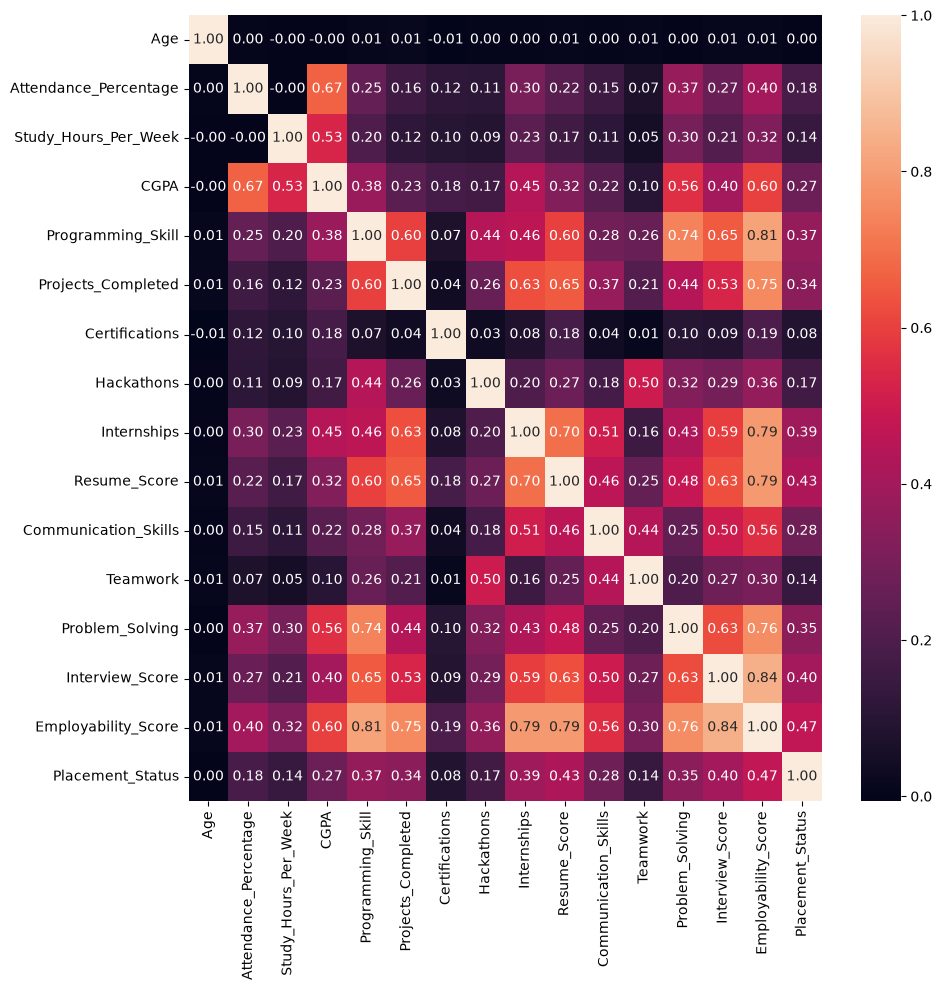

In [20]:
plt.figure(figsize=(10,10))
sns.heatmap(corrMtrx,annot=True,fmt=".2f")
plt.tight_layout()

## EDA Summary

1. The dataset contains 50,000 student records with academic, technical, professional, and demographic features.
2. Placement_Status was selected as the target variable for the classification task.
3. Several features were identified as potential data leakage because they contain information associated with the placement outcome, including Starting_Salary_USD, Company_Tier, Placement_Mode, and Career_Field. These will be excluded from model training.
3. Numerical and categorical features were explored using distributions, group comparisons, and correlation analysis.
4. Features such as Employability_Score, Resume_Score, Interview_Score, Internships, and Programming_Skill showed relatively stronger positive linear associations with placement status.
5. Correlation was used for exploration rather than automatic feature selection, since a weak individual correlation does not necessarily mean a feature is useless to a machine-learning model.
6. Employability_Score showed strong correlations with several other features, suggesting possible redundancy; this will be considered during model evaluation rather than assumed beforehand.

Next: The cleaned feature set will be prepared for preprocessing and model training.